In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("student_profiles.csv")

df.head()

,Student_ID,Python,SQL,Excel,Statistics,Data Analysis,Machine Learning,Deep Learning,NLP,Power BI,...,JavaScript,HTML_CSS,C++,Git,Linux,Cloud,Cybersecurity,Communication,Problem Solving,Target_Career
0,S001,5,4,2,5,5,5,3,2,2,...,1,1,0,4,2,2,0,4,5,Data Scientist
1,S002,4,5,5,3,5,2,0,0,5,...,1,1,0,4,1,1,0,5,4,Data Analyst
2,S003,3,2,1,1,1,1,0,0,0,...,4,3,4,5,3,2,1,4,5,Software Developer
3,S004,2,2,1,0,1,0,0,0,0,...,5,5,0,4,2,2,0,4,4,Web Developer
4,S005,5,3,1,4,4,5,5,4,1,...,2,1,2,5,5,4,0,3,5,ML Engineer


In [3]:
df.shape

(40, 22)

In [4]:
X = df.drop(columns=["Student_ID", "Target_Career"])

y = df["Target_Career"]

In [5]:
y.value_counts()

,count
Target_Career,
Data Scientist,5
Data Analyst,5
Software Developer,5
Web Developer,5
ML Engineer,5
Business Analyst,5
Cybersecurity Analyst,5
Cloud Engineer,5


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 32
Testing samples: 8


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [9]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [10]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [11]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

Logistic Regression Accuracy: 1.0


In [12]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

                       precision    recall  f1-score   support

     Business Analyst       1.00      1.00      1.00         1
       Cloud Engineer       1.00      1.00      1.00         1
Cybersecurity Analyst       1.00      1.00      1.00         1
         Data Analyst       1.00      1.00      1.00         1
       Data Scientist       1.00      1.00      1.00         1
          ML Engineer       1.00      1.00      1.00         1
   Software Developer       1.00      1.00      1.00         1
        Web Developer       1.00      1.00      1.00         1

             accuracy                           1.00         8
            macro avg       1.00      1.00      1.00         8
         weighted avg       1.00      1.00      1.00         8



In [13]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 1]]


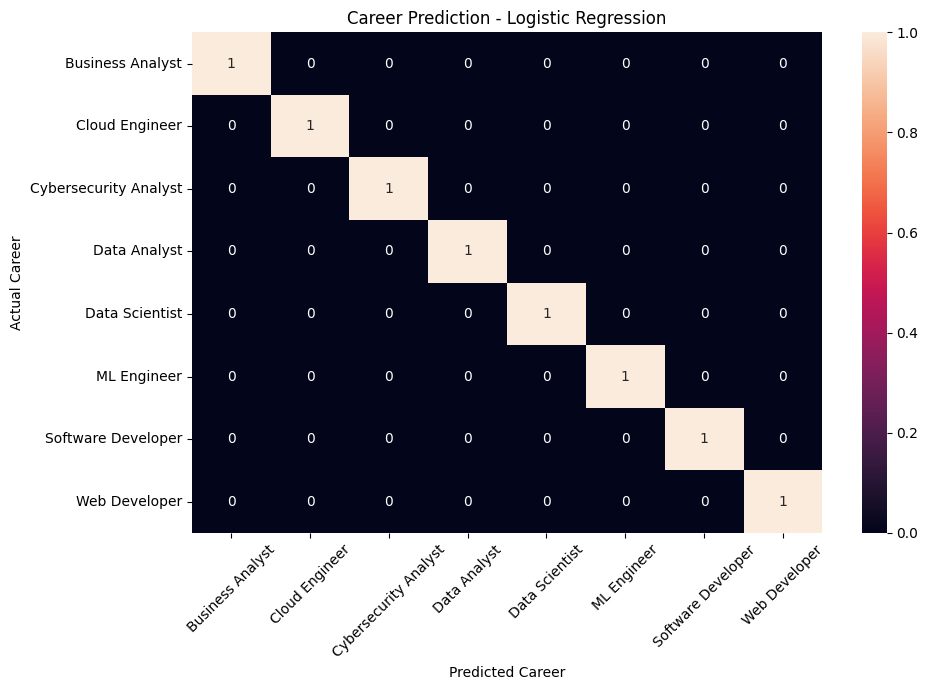

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.xlabel("Predicted Career")
plt.ylabel("Actual Career")
plt.title("Career Prediction - Logistic Regression")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [16]:
y_pred_rf = rf_model.predict(X_test)

In [17]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
